<a href="https://colab.research.google.com/github/wesleylelo/CDIA_AI_COLAB/blob/develop/HIPERPARAMETROS_GRID_SERCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
###################################################################
##################################################################
#Instituição: SENAI - CIMATEC
#Curso: Ciência de Dados e Inteligência Artificial (CDIA)
#Disciplina: Inteligência Artificial II
#Autor: Carlos Fernando Arraz | Data: Fevereiro, 2024
#UA02 - Roteiro de Prática Guiada: Hiperparâmetros (Grid Search)
###################################################################
###################################################################

---

INSTRUÇÕES GERAIS:

---



1 - Realize uma cópia deste arquivo em seu repositório pessoal para iniciar a prática (usar o e-mail institucional para isso);

2 - Reveja o conteúdo teórico e os exemplos práticos vistos até agora na graduação para pontecializar o aprendizado;

3 -Leia a teoria e acompanhe o script python linha a linha e seus comentários (execute as células com **shift + ENTER** ou botão play à esquerda de cada comando/bloco de código), estudando as estruturas, as partes do algoritmo e a lógica proposta;

4 - Execute, modifique, teste e experimente o conteúdo ao máximo para internalizar o conhecimento; e

5- Compare os resultados com bibliotecas de machine learning consagradas no desenvolvimento de soluções em AI.

#Este roteiro tem como objetivo mostrar uma introdução a busca de hiperparâmetros (grid search) quando aplicamos os algoritmos de machine learning. O grid search é uma técnica mais clássica, entretanto é uma das técnicas consagradas através de um script em python 🐍.



# PARTE I: aplicando o SVM para classificação no dataset Iris usando apenas o hiperparâmetro kernel = "sigmoid"

Nesta parte vamos fazer o treinamento do algoritmo usando apenas o hiperparâmetro Kernel = "sigmpoid" e avaliar os resultados na partição de teste

In [2]:
#Importar as bibliotecas
from sklearn import svm, datasets
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
#Carregar a base de dados
iris = datasets.load_iris()

In [4]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [12]:
#Definir quais são os hiperparametros a serem verificados

#Instanciar o SVC com o parâmtro kernel = "sigmoid"
clf = svm.SVC(kernel = 'sigmoid')

#Separar base de treino e teste
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.33 )

#Fazer o treino do algoritmo
clf.fit(X_train, y_train)

SVC(kernel='sigmoid')

In [13]:
#Verificar a perfomance do classificador
clf.score(X_test, y_test)

0.28

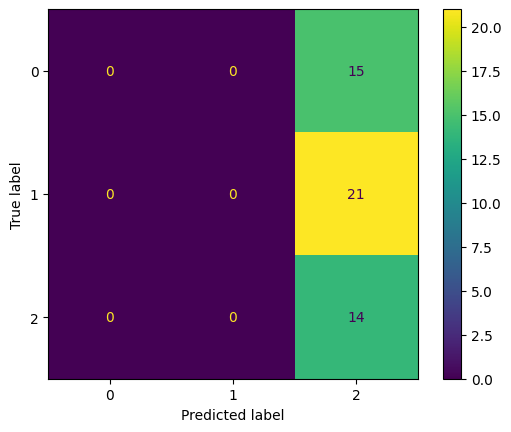

In [14]:
#Colocar os resultados numa matriz de confusão
predictions = clf.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_
                            )
disp.plot()
plt.show()

## Obs: veja que temos resultados muito pobres. Daí, precisamos testar outros possíveis parâmetros capazes de aprimorar os resultados do algoritmo SVM. Como podemos fazer isso de forma mais automatizada ?

#Parte II - Aplicar o algoritmo SVM usando a busca de hiperparâmetros (grid search)

In [15]:
#Definir quais são os hiperparametros a serem verificados

#Buscar os resultados conforme a opções a seguir: kernel e C
parameters = {'kernel':("linear", "poly","rbf", "sigmoid" ), 'C':[0.25, 0.5, 1, 2, 5, 7, 10]}

#Instanciar o SVC
svc = svm.SVC()

#Utilizar o grid seaarch para avaliar as combinações
clf = GridSearchCV(svc, parameters)

#Separar base de treino e teste
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

#Fazer o treino do algoritmo com verificação cross validation (CV)
clf.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.25, 0.5, 1, 2, 5, 7, 10],
                         'kernel': ('linear', 'poly', 'rbf', 'sigmoid')})

In [16]:
#Ver o melhor dos scores entre todos
clf.best_score_

np.float64(0.9666666666666668)

In [17]:
#Confirmar quais os melhores hiperparâmetros alcaçam os melhores resultados
clf.best_params_

{'C': 5, 'kernel': 'linear'}

In [18]:
#Verificar score com novos hiperparâmetros
clf.score(X_test, y_test)

0.9666666666666667

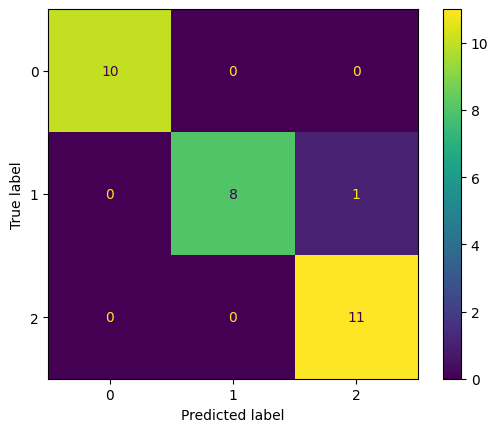

In [19]:
#Colocar resultados numa matriz de confusão
predictions = clf.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_
                            )
disp.plot()
plt.show()

## Parte III - Faça modificações no código e anote suas observações. Quaisquer dúvidas postar no fórum para ampla discussão.

Referências:

[1] PEREIRA, Eduardo. Computação Evolucionária: Aplique os algoritmos genéticos com Python e Numpy. Casa do Código, 2020.

[2] FACELI, Katti; et al. Inteligência artificial: uma abordagem de aprendizado de máquina. Rio de Janeiro: Grupo GEN, 2021. E-book. ISBN 9788521637509.

[3] Géron, A. (2022). Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow. " O'Reilly Media, Inc.".

[4] NETTO, Amilcar; MACIEL, Francisco. Python para data science e machine learning descomplicado. Rio de Janeiro: Alta Books, 2021. E-book. ISBN 9786555203172.

[5] Fonte online AWS. O que é ajuste de hiperparâmetros. Página online https://aws.amazon.com/pt/what-is/hyperparameter-tuning/  acessada em 29/01/2024.

[6] Fonte online Scikit-Learn. Tuning the hyper-parameters of an estimator. Página online https://scikit-learn.org/stable/modules/grid_search.html#tuning-the-hyper-parameters-of-an-estimator acessada em 30/01/2024.